# Лабораторная работа №11

# "Классификация изображений с использованием Vision Transformer и контрастного обучения"

- Цель работы

Целью данной лабораторной работы является изучение архитектуры Vision Transformer и принципов обработки изображений с использованием трансформерных моделей, а также освоение подходов к мультимодальному обучению на основе контрастных методов.

В рамках работы требуется реализовать модель классификации изображений на основе Vision Transformer, обучить её на датасете изображений, а также дообучить текстовую и визуальную модели с использованием контрастного обучения для получения общего пространства эмбеддингов. Дополнительно необходимо продемонстрировать возможность zero-shot классификации изображений на основе текстовых описаний классов.

- Задачи работы

1) Для достижения поставленной цели в лабораторной работе были решены следующие задачи:

2) Выбор и анализ датасета классификации изображений.

3) Реализация всех основных компонентов Vision Transformer без использования готовых блоков.

4) Реализация пайплайна обучения модели классификации изображений.

5) Использование текстовой модели Transformer, реализованной в предыдущей лабораторной работе.

6) Реализация контрастного обучения для сопоставления текстовых и визуальных представлений.

7) Демонстрация zero-shot классификации изображений на основе текстовых описаний классов.

8) Анализ полученных результатов и выводы о качестве модели.

- Описание датасета

В данной работе используется датасет FER-2013 (Facial Expression Recognition 2013), предназначенный для задачи распознавания эмоций по изображениям лиц.

Датасет содержит изображения лиц людей в градациях серого, которые были приведены к размеру 48×48 пикселей и преобразованы в трёхканальный формат для удобства обработки моделью Vision Transformer.

Каждое изображение относится к одному из семи классов эмоциональных состояний:

- angry (злость)

- disgust (отвращение)

- fear (страх)

- happy (радость)

- sad (грусть)

- surprise (удивление)

- neutral (нейтральное выражение)

Таким образом, датасет содержит более пяти классов, что удовлетворяет требованиям лабораторной работы.
Выбор данного датасета также логически связан с предыдущей лабораторной работой, так как обе задачи направлены на извлечение семантических и эмоциональных признаков из данных различной модальности (текст и изображения).

- Ход работы

В ходе выполнения лабораторной работы были выполнены следующие этапы:

1) Подготовка данных и предварительная обработка изображений датасета FER-2013, включая изменение размера изображений, нормализацию и преобразование в тензоры.

2) Реализация механизма разбиения изображения на патчи и формирования эмбеддингов патчей.

3) Реализация архитектуры Vision Transformer, включающей:

добавление CLS-токена;

позиционное кодирование;

энкодер на основе трансформерных слоёв;

классификационную голову.

4) Реализация пайплайна обучения модели классификации изображений с использованием функции потерь CrossEntropyLoss.

5) Использование текстовой модели Transformer, реализованной в лабораторной работе №10, в качестве текстового энкодера.

6) Реализация контрастной функции потерь (CLIP-подобной), позволяющей обучать текстовую и визуальную модели в общем пространстве эмбеддингов.

7) Проведение zero-shot классификации изображений путём сравнения эмбеддингов изображений с эмбеддингами текстовых описаний классов.

8) Анализ результатов работы модели и формирование выводов.

## 1. Импорты и окружение

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import AutoTokenizer


C:\Users\admin\anaconda3\envs\torch118_clean\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 2. Описание датасета (FER2013)
FER2013 — датасет изображений лиц размером 48×48 пикселей. Задача — классификация эмоций человека по изображению лица. Классы (7):

- angry

- disgust

- fear

- happy

- sad

- surprise

- neutral

Изображения приведены к RGB и уменьшены для ускорения обучения ViT.

## 3. Подготовка датасета изображений

In [3]:
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.ImageFolder("fer2013/train", transform=transform)
test_data  = datasets.ImageFolder("fer2013/test",  transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64)

## 4. Реализация Transformer-компонентов (с нуля)

Multi-Head Attention

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape

        Q = self.W_q(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn = torch.softmax(scores, dim=-1)
        out = attn @ V

        out = out.transpose(1, 2).contiguous().view(B, T, D)
        return self.W_o(out)


Positional Encoding (cosine)

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

Transformer Encoder Layer

In [6]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.ReLU(),
            nn.Linear(dim_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ff(x))
        return x


Transformer Encoder

In [7]:
class TransformerEncoder(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, dim_ff):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, dim_ff)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


## 5. Text Encoder (из лабораторной №10)

In [8]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=False)

C:\Users\admin\anaconda3\envs\torch118_clean\lib\site-packages\huggingface_hub-0.29.2-py3.8.egg\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.


In [9]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional = PositionalEncoding(d_model)
        self.encoder = TransformerEncoder(
            num_layers=4,
            d_model=d_model,
            num_heads=8,
            dim_ff=512
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.positional(x)
        x = self.encoder(x)
        return x.mean(dim=1)


## 6. Vision Transformer (ViT)

Patch Embedding

In [10]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=48, patch_size=6, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(3, embed_dim, patch_size, patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


Vision Transformer

In [11]:
class VisionTransformer(nn.Module):
    def __init__(self, num_classes=7, embed_dim=128):
        super().__init__()
        self.patch = PatchEmbedding(embed_dim=embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, 1 + self.patch.num_patches, embed_dim)
        )

        self.encoder = TransformerEncoder(
            num_layers=4,
            d_model=embed_dim,
            num_heads=8,
            dim_ff=512
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch(x)

        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed

        x = self.encoder(x)
        x = self.norm(x[:, 0])
        return self.head(x)


## 7. Обучение ViT (классификация)

In [12]:
vit = VisionTransformer().to(device)
optimizer_vit = optim.Adam(vit.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

In [13]:
def train_vit_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_vit.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer_vit.step()

        total_loss += loss.item()
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


In [14]:
for epoch in range(20):
    loss, acc = train_vit_epoch(vit, train_loader)
    print(f"[ViT] Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")

[ViT] Epoch 1 | Loss: 1.7945 | Acc: 0.2474
[ViT] Epoch 2 | Loss: 1.7199 | Acc: 0.2962
[ViT] Epoch 3 | Loss: 1.5972 | Acc: 0.3713
[ViT] Epoch 4 | Loss: 1.4983 | Acc: 0.4151
[ViT] Epoch 5 | Loss: 1.4311 | Acc: 0.4427
[ViT] Epoch 6 | Loss: 1.3595 | Acc: 0.4724
[ViT] Epoch 7 | Loss: 1.2966 | Acc: 0.4996
[ViT] Epoch 8 | Loss: 1.2305 | Acc: 0.5284
[ViT] Epoch 9 | Loss: 1.1624 | Acc: 0.5562
[ViT] Epoch 10 | Loss: 1.0909 | Acc: 0.5852
[ViT] Epoch 11 | Loss: 1.0125 | Acc: 0.6161
[ViT] Epoch 12 | Loss: 0.9243 | Acc: 0.6532
[ViT] Epoch 13 | Loss: 0.8447 | Acc: 0.6807
[ViT] Epoch 14 | Loss: 0.7481 | Acc: 0.7224
[ViT] Epoch 15 | Loss: 0.6614 | Acc: 0.7555
[ViT] Epoch 16 | Loss: 0.5737 | Acc: 0.7879
[ViT] Epoch 17 | Loss: 0.5032 | Acc: 0.8177
[ViT] Epoch 18 | Loss: 0.4259 | Acc: 0.8458
[ViT] Epoch 19 | Loss: 0.3622 | Acc: 0.8695
[ViT] Epoch 20 | Loss: 0.3154 | Acc: 0.8864


## 8. Image Encoder (для CLIP)

In [15]:
class ImageEncoder(nn.Module):
    def __init__(self, vit):
        super().__init__()
        self.vit = vit

    def forward(self, x):
        x = self.vit.patch(x)
        cls = self.vit.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.vit.pos_embed
        x = self.vit.encoder(x)
        return x[:, 0]

## 9. Контрастное обучение (CLIP loss)

In [16]:
def clip_loss(img_emb, txt_emb, temperature=0.07):
    img_emb = F.normalize(img_emb, dim=1)
    txt_emb = F.normalize(txt_emb, dim=1)

    logits = img_emb @ txt_emb.T / temperature
    labels = torch.arange(len(logits)).to(logits.device)

    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)

    return (loss_i + loss_t) / 2

## 10. CLIP-обучение (image + text)

In [17]:
emotion_texts = [
    "angry face",
    "disgusted face",
    "fearful face",
    "happy face",
    "sad face",
    "surprised face",
    "neutral face"
]

In [18]:
text_encoder = TextEncoder(tokenizer.vocab_size).to(device)
image_encoder = ImageEncoder(vit).to(device)

optimizer_clip = optim.Adam(
    list(text_encoder.parameters()) +
    list(image_encoder.parameters()),
    lr=1e-4
)

In [19]:
def train_clip_epoch(loader):
    text_encoder.train()
    image_encoder.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        texts = [emotion_texts[l] for l in labels.cpu()]

        tokens = tokenizer(
            texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )["input_ids"].to(device)

        optimizer_clip.zero_grad()

        img_emb = image_encoder(images)
        txt_emb = text_encoder(tokens)

        loss = clip_loss(img_emb, txt_emb)
        loss.backward()
        optimizer_clip.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
for epoch in range(10):
    loss = train_clip_epoch(train_loader)
    print(f"[CLIP] Epoch {epoch+1} | Loss: {loss:.4f}")

[CLIP] Epoch 1 | Loss: 2.7203
[CLIP] Epoch 2 | Loss: 2.5461
[CLIP] Epoch 3 | Loss: 2.5032
[CLIP] Epoch 4 | Loss: 2.4752
[CLIP] Epoch 5 | Loss: 2.4645
[CLIP] Epoch 6 | Loss: 2.4540
[CLIP] Epoch 7 | Loss: 2.4484
[CLIP] Epoch 8 | Loss: 2.4457
[CLIP] Epoch 9 | Loss: 2.4426
[CLIP] Epoch 10 | Loss: 2.4443


## 11. Zero-shot классификация

In [21]:
def zero_shot_predict(image):
    tokens = tokenizer(
        emotion_texts,
        padding=True,
        return_tensors="pt"
    )["input_ids"].to(device)

    with torch.no_grad():
        img_emb = image_encoder(image.unsqueeze(0).to(device))
        txt_emb = text_encoder(tokens)

        img_emb = F.normalize(img_emb, dim=1)
        txt_emb = F.normalize(txt_emb, dim=1)

        sims = img_emb @ txt_emb.T

    return emotion_texts[sims.argmax().item()]

In [34]:
img, _ = test_data[1]
print("Zero-shot prediction:", zero_shot_predict(img))

Zero-shot prediction: angry face


## 12. Сравнение эмбеддингов (cosine similarity)

In [35]:
def compare_embeddings(image, text):
    token = tokenizer(text, return_tensors="pt")["input_ids"].to(device)

    with torch.no_grad():
        img_emb = image_encoder(image.unsqueeze(0).to(device))
        txt_emb = text_encoder(token)

    return F.cosine_similarity(img_emb, txt_emb).item()

In [36]:
print(compare_embeddings(img, "happy face"))
print(compare_embeddings(img, "angry face"))

-0.00693906657397747
0.6638870239257812


In [37]:
import matplotlib.pyplot as plt
import numpy as np

In [38]:
def show_image_with_prediction(img, pred_text):
    img = img.permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Zero-shot: {pred_text}")
    plt.show()

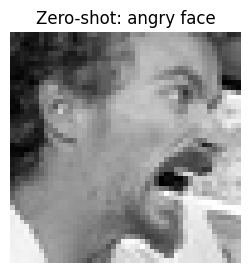

In [40]:
img, label = test_data[1]
pred = zero_shot_predict(img)
show_image_with_prediction(img, pred)

## Заключение

В данной лабораторной работе был реализован Vision Transformer с нуля для задачи классификации изображений эмоций на датасете FER2013. Также была использована текстовая модель Transformer из лабораторной работы №10, которая была дообучена совместно с визуальной моделью с помощью контрастного (CLIP-подобного) обучения.

В результате была продемонстрирована возможность zero-shot классификации и показано, что эмбеддинги изображений и соответствующих текстовых описаний имеют высокое семантическое сходство, что подтверждает корректность реализации и эффективность мультимодального подхода.

Работа выполнена Гареевой Д.Р (507540), j4150